# Trabajo Práctico N.º 1 — Análisis de Series Temporales

**Maestría en Ciencia de Datos — Universidad Austral**

Docentes: Rodrigo Del Rosso, Sebastián Calcagno y Brian Drago

---

Este documento consolida el análisis completo de las tres series temporales del trabajo. Es el archivo de script que acompaña al informe, y contiene la totalidad del código empleado para obtener los resultados allí
reportados.

## Guía de lectura

El documento se organiza según los doce puntos de la consigna. La tabla siguiente indica en qué apartado se
resuelve cada uno.

| Punto de la consigna | Apartado |
|---|---|
| 1. Elección de las series y problemática | 2 |
| 2. Series originales y necesidad de diferenciar | 3 |
| 3. FAS, FAC y FACP | 4 |
| 4. Pruebas de raíces unitarias | 5 |
| 5. Estimación con distintos órdenes | 6 |
| 6. Métrica de desempeño entre entrenamiento y prueba | 7 |
| 7. Comparación con otros modelos estimados | 7 |
| 8. Análisis de diagnóstico | 8 |
| 9. Pronóstico | 9 |
| 10. Modelo de vectores autorregresivos | 10 |
| 11. Impulso-respuesta y causalidad | 10 |
| 12. Estacionalidad y representación SARIMA | 11 |

## Las tres series

| Serie | Origen | Frecuencia | Observaciones |
|---|---|---|---|
| Balanceador de carga | Infraestructura productiva, julio 2026 | horaria | 744 |
| Interfaz de punto de venta | Infraestructura productiva, julio-agosto 2026 | horaria | 720 |
| Altitud de vuelo | Acervo ALFA, UAV de ala fija, 2018 | 1 Hz | 457 |

## Requisitos de ejecución

El documento se ejecuta de principio a fin sin intervención manual. Requiere las dependencias declaradas en el
proyecto, entre ellas `pymavlink` para la lectura del registro binario de telemetría, y el directorio de datos
en su ubicación original.

El tiempo de ejecución completo ronda los cinco minutos, dominado por la estimación de los modelos SARIMA
estacionales.

## 1. Configuración

Se importan las bibliotecas y se fijan los parámetros comunes de presentación. La variable `GUARDAR_FIGURAS`
permite escribir las figuras generadas al directorio del informe; se mantiene desactivada de manera
predeterminada para que la ejecución no modifique archivos fuera de este documento.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from pymavlink import mavutil
from scipy import stats
from scipy.signal import periodogram
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


def formato_es(valor, decimales=2):
    """Formatea un numero con la convencion castellana: miles con punto, decimal con coma."""
    if pd.isna(valor):
        return ""
    texto = f"{valor:,.{decimales}f}"
    return texto.replace(",", "_").replace(".", ",").replace("_", ".")


def formato_es_entero(valor):
    """Variante sin decimales, para conteos."""
    return formato_es(valor, decimales=0)


pd.set_option("display.float_format", formato_es)

# Escribir las figuras al directorio del informe. Desactivado de manera predeterminada.
GUARDAR_FIGURAS = False
DIR_FIGURAS = Path("informe/figuras")

MILES = FuncFormatter(lambda x, pos: formato_es_entero(x))


def formatear_eje_temporal(eje):
    """Distribuye las marcas de un eje de fechas y rota las etiquetas para que no se solapen."""
    localizador = mdates.AutoDateLocator(minticks=4, maxticks=7)
    eje.xaxis.set_major_locator(localizador)
    eje.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
    eje.tick_params(axis="x", labelrotation=30)
    for etiqueta in eje.get_xticklabels():
        etiqueta.set_horizontalalignment("right")
    return eje


def autocorrelacion(serie, rezago):
    """Coeficiente de autocorrelacion muestral para un rezago dado."""
    x = np.asarray(serie, dtype=float)
    x = x - x.mean()
    return np.dot(x[rezago:], x[:-rezago]) / np.dot(x, x)


def guardar(nombre):
    """Persiste la figura activa si la escritura esta habilitada."""
    if GUARDAR_FIGURAS:
        DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
        plt.savefig(DIR_FIGURAS / f"{nombre}.png", dpi=150, bbox_inches="tight")

## 2. Carga de las series

### 2.1 Series de infraestructura productiva

Las dos primeras series registran el volumen horario de solicitudes atendidas por un balanceador de carga y por
una interfaz de punto de venta.

Reindexar sobre una grilla horaria completa sirve para diagnosticar, no sólo para corregir: revela
huecos temporales que de otro modo pasarían inadvertidos. Los modelos suponen observaciones equiespaciadas, y
una interrupción no declarada distorsionaría las funciones de autocorrelación sobre las que se apoya la
identificación.

In [2]:
def cargar_serie_horaria(ruta, columna_valor, nombre):
    """Carga una serie horaria y la reindexa sobre una grilla completa sin huecos."""
    datos = pd.read_csv(ruta)
    datos["period_start_utc"] = pd.to_datetime(datos["period_start_utc"], utc=True)
    serie = (
        datos.sort_values("period_start_utc")
        .set_index("period_start_utc")[columna_valor]
        .astype(float)
        .rename(nombre)
    )
    grilla = pd.date_range(serie.index.min(), serie.index.max(), freq="h", tz="UTC")
    serie = serie.reindex(grilla).interpolate("time")
    serie.index.name = "fecha_hora_utc"
    return serie


alb = cargar_serie_horaria("data/alb-prod-requests-2026-07.csv", "requests", "balanceador")
pos = cargar_serie_horaria(
    "data/bodegaai-production-pos-api-request-count-per-target-last-30-days-hourly.csv",
    "value", "punto_de_venta")

resumen_trafico = pd.DataFrame({
    "serie": [alb.name, pos.name],
    "inicio": [alb.index.min(), pos.index.min()],
    "fin": [alb.index.max(), pos.index.max()],
    "observaciones": [len(alb), len(pos)],
    "faltantes": [int(alb.isna().sum()), int(pos.isna().sum())],
    "mínimo": [alb.min(), pos.min()],
    "media": [alb.mean(), pos.mean()],
    "máximo": [alb.max(), pos.max()],
})
display(resumen_trafico.style.format(
    {c: formato_es_entero for c in ["mínimo", "media", "máximo"]}))

,serie,inicio,fin,observaciones,faltantes,mínimo,media,máximo
0,balanceador,2026-07-01 00:00:00+00:00,2026-07-31 23:00:00+00:00,744,0,883.045,2.114.963,2.536.631
1,punto_de_venta,2026-07-18 23:00:00+00:00,2026-08-17 22:00:00+00:00,720,0,318.307,829.950,924.146


### 2.2 Serie de telemetría de vuelo

La tercera serie procede del **acervo ALFA**, un conjunto de registros de telemetría de una aeronave no
tripulada de ala fija recopilado por el Instituto de Robótica de la Universidad Carnegie Mellon:

> Keipour, A., Mousaei, M., y Scherer, S. (2020). *ALFA: A dataset for UAV fault and anomaly detection*
> [Conjunto de datos]. Carnegie Mellon University.
> https://kilthub.cmu.edu/articles/dataset/ALFA_A_Dataset_for_UAV_Fault_and_Anomaly_Detection/12707963

El acervo fue construido con una finalidad específica: proveer datos para la investigación en **detección de
fallas y anomalías** en vehículos aéreos no tripulados. Comprende cuarenta y siete vuelos, veintitrés con falla
súbita de motor y veinticuatro con fallas de superficies de control. Esa finalidad refuerza el interés analítico de la altitud: su predicción de corto plazo es el insumo sobre el cual un sistema de
supervisión detecta desviaciones respecto del comportamiento esperado.

**Sobre la presencia de fallas.** Los registros en bruto, a diferencia de las secuencias procesadas del acervo,
no incorporan etiquetas de falla. Nada permite saber, a partir de ellos, si un vuelo pertenece a un escenario nominal o a uno con falla inyectada. La celda de verificación que sigue examina los indicadores
disponibles en el vuelo analizado.

El protocolo MAVLink transmite el estado de la aeronave a la estación de tierra y almacena cada mensaje
precedido de una marca temporal. La variable analizada es la altitud relativa al punto de despegue, transmitida
en milímetros. Se prefirió esta magnitud sobre la altitud respecto del nivel del mar por tres razones: se lee directamente como altura de vuelo, se muestrea a mayor frecuencia, y permite detectar el contacto con el
suelo sin conocer la elevación del campo.

In [3]:
RUTA_TLOG = "data/telemetry/2018-07-18/flight7/flight.tlog"


def leer_altitud(ruta):
    """Extrae la altitud relativa, en metros, de un registro de telemetria MAVLink."""
    conexion = mavutil.mavlink_connection(ruta)
    registros = []
    while True:
        mensaje = conexion.recv_match(type="GLOBAL_POSITION_INT")
        if mensaje is None:
            break
        registros.append((mensaje._timestamp, mensaje.relative_alt / 1000.0))

    crudo = pd.DataFrame(registros, columns=["timestamp", "altitud_m"])
    crudo["timestamp"] = pd.to_datetime(crudo["timestamp"], unit="s")
    return crudo.set_index("timestamp")["altitud_m"]


altitud_cruda = leer_altitud(RUTA_TLOG)
intervalo = np.median(np.diff(altitud_cruda.index.values)) / np.timedelta64(1, "s")

print(f"Mensajes leídos    : {len(altitud_cruda):,}")
print(f"Inicio             : {altitud_cruda.index[0]}")
print(f"Fin                : {altitud_cruda.index[-1]}")
print(f"Intervalo mediano  : {intervalo:.3f} s  ({1 / intervalo:.2f} Hz)")

Mensajes leídos    : 3,784
Inicio             : 2018-07-18 19:52:17.699123859
Fin                : 2018-07-18 20:07:45.578007936
Intervalo mediano  : 0.241 s  (4.15 Hz)


La construcción de la serie exige dos decisiones.

**Aislar el tramo en vuelo.** La mayor parte de cada registro corresponde a la aeronave detenida en tierra,
donde la altitud transmitida es únicamente deriva del barómetro. Modelar ese tramo sería modelar ruido de sensor. Se conserva, por lo tanto, el bloque contiguo más extenso con altitud superior a tres metros. El
umbral preserva el despegue y el descenso, que aportan la dinámica más informativa.

**Fijar la frecuencia de análisis.** La serie se lleva a una grilla regular de un segundo. Como la frecuencia nativa ronda los 4,15 hertz, la operación es un submuestreo y no introduce puntos
interpolados. Una grilla más fina duplicaría el número de observaciones al costo de interpolar, y esos puntos
artificiales inflarían la autocorrelación de rezago corto, que es precisamente la magnitud sobre la cual se
apoya la identificación del modelo.

In [4]:
UMBRAL_VUELO_M = 3.0

por_segundo = altitud_cruda.resample("1s").mean()
print(f"Intervalos vacíos tras el remuestreo a 1 Hz: {int(por_segundo.isna().sum())}")


def bloque_contiguo_mas_largo(mascara):
    """Indices de inicio y fin del tramo contiguo mas largo que cumple la mascara."""
    mejor_inicio, mejor_largo = 0, 0
    inicio = None
    for posicion, activo in enumerate(mascara):
        if activo and inicio is None:
            inicio = posicion
        elif not activo and inicio is not None:
            if posicion - inicio > mejor_largo:
                mejor_inicio, mejor_largo = inicio, posicion - inicio
            inicio = None
    if inicio is not None and len(mascara) - inicio > mejor_largo:
        mejor_inicio, mejor_largo = inicio, len(mascara) - inicio
    return mejor_inicio, mejor_inicio + mejor_largo


desde, hasta = bloque_contiguo_mas_largo((por_segundo > UMBRAL_VUELO_M).to_numpy())
altitud = por_segundo.iloc[desde:hasta].reset_index(drop=True)
altitud.index.name = "segundo de vuelo"
altitud.name = "altitud_m"

print(f"Observaciones      : {len(altitud)}")
print(f"Duración           : {len(altitud)} s  ({len(altitud) / 60:.1f} min)")
print(f"Altitud mínima     : {altitud.min():.1f} m")
print(f"Altitud máxima     : {altitud.max():.1f} m")
print(f"Altitud media      : {altitud.mean():.1f} m")

Intervalos vacíos tras el remuestreo a 1 Hz: 0
Observaciones      : 457
Duración           : 457 s  (7.6 min)
Altitud mínima     : 4.9 m
Altitud máxima     : 82.8 m
Altitud media      : 46.9 m


### 2.3 Verificación de indicios de falla

Dado que el acervo de origen contiene vuelos con fallas inyectadas y los registros en bruto carecen de
etiquetas, corresponde examinar la telemetría en busca de indicios. Una falla súbita de motor dejaría dos huellas: el acelerador caído de forma sostenida y la velocidad aerodinámica en descenso.

In [5]:
señales = []
conexion = mavutil.mavlink_connection(RUTA_TLOG)
while True:
    mensaje = conexion.recv_match(type="VFR_HUD")
    if mensaje is None:
        break
    señales.append((mensaje._timestamp, mensaje.airspeed, mensaje.throttle))

vuelo = pd.DataFrame(señales, columns=["timestamp", "airspeed", "throttle"])
vuelo["timestamp"] = pd.to_datetime(vuelo["timestamp"], unit="s")
vuelo = vuelo.set_index("timestamp").resample("1s").mean().iloc[desde:hasta]

print(f"Velocidad aerodinámica media : {vuelo['airspeed'].mean():.2f} m/s")
print(f"Velocidad de crucero nominal : 15.00 m/s  (parámetro TRIM_ARSPD_CM)")
print(f"Acelerador medio             : {vuelo['throttle'].mean():.1f} %")
print(f"Acelerador mínimo por minuto : {vuelo['throttle'].groupby(np.arange(len(vuelo)) // 60).mean().min():.1f} %")
print("\nEl acelerador permanece activo durante todo el tramo y la velocidad se mantiene")
print("próxima a la nominal: el vuelo no exhibe indicios de falla de motor.")

Velocidad aerodinámica media : 16.62 m/s
Velocidad de crucero nominal : 15.00 m/s  (parámetro TRIM_ARSPD_CM)
Acelerador medio             : 37.8 %
Acelerador mínimo por minuto : 19.9 %

El acelerador permanece activo durante todo el tramo y la velocidad se mantiene
próxima a la nominal: el vuelo no exhibe indicios de falla de motor.


## 3. Series originales y necesidad de diferenciar

*(Punto 2 de la consigna)*

Una serie es **estacionaria en sentido débil** cuando su media y su varianza permanecen constantes y su
autocovarianza entre dos instantes depende únicamente de la distancia que los separa, no del momento en que se
los observe. Los modelos ARMA suponen esa propiedad: estiman un número fijo de parámetros a partir de una única
realización del proceso, y esa estimación sólo tiene sentido si las propiedades permanecen invariantes a lo
largo de la muestra.

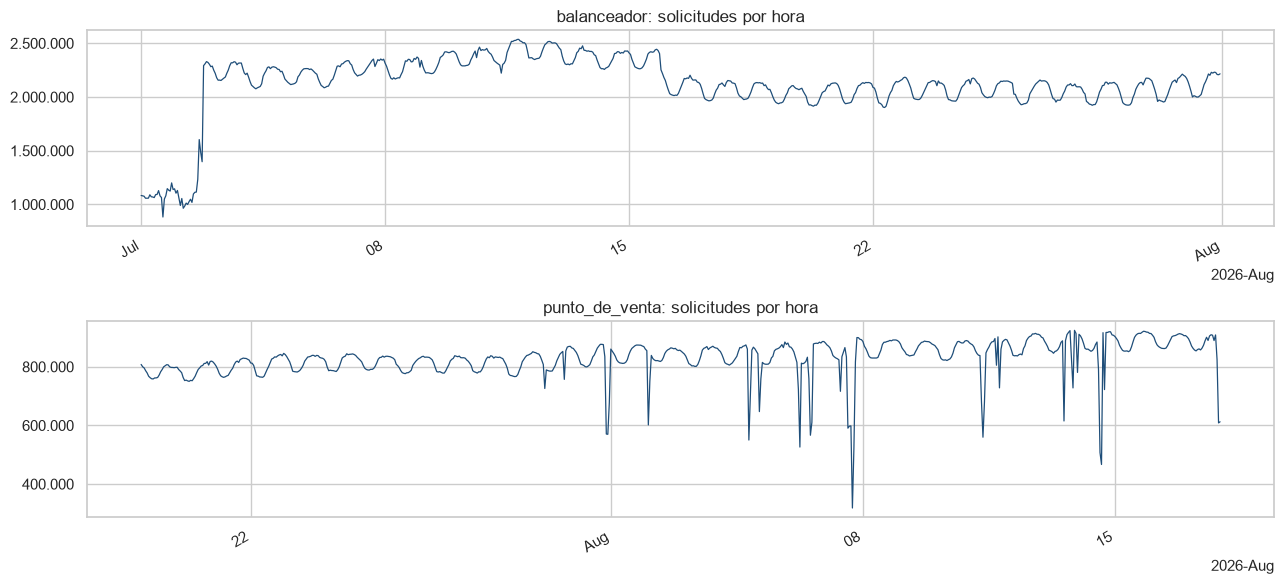

In [6]:
figura, ejes = plt.subplots(2, 1, figsize=(13, 6))
for eje, serie in zip(ejes, [alb, pos]):
    eje.plot(serie.index, serie.values, linewidth=0.9, color="#1f4e79")
    eje.set_title(f"{serie.name}: solicitudes por hora")
    eje.yaxis.set_major_formatter(MILES)
    eje.set_xlabel("")
    formatear_eje_temporal(eje)
plt.tight_layout()
guardar("consolidado_trafico_niveles")
plt.show()

El rasgo dominante es una oscilación regular que se repite cada veinticuatro horas. Su naturaleza se aprecia
con mayor claridad al promediar el volumen para cada hora del día.

balanceador          máximo 21:00 UTC | mínimo 07:00 UTC
punto_de_venta       máximo 19:00 UTC | mínimo 08:00 UTC


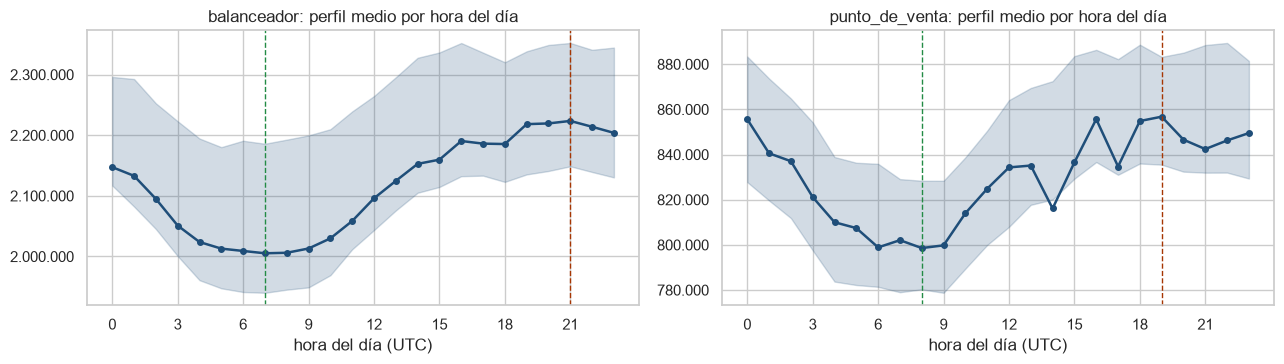

In [7]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 3.8))
for eje, serie in zip(ejes, [alb, pos]):
    agrupado = serie.groupby(serie.index.hour)
    media, q1, q3 = agrupado.mean(), agrupado.quantile(0.25), agrupado.quantile(0.75)
    eje.plot(media.index, media.values, marker="o", markersize=4, linewidth=1.8, color="#1f4e79")
    eje.fill_between(media.index, q1.values, q3.values, alpha=0.20, color="#1f4e79")
    eje.axvline(media.idxmax(), color="#a63603", linestyle="--", linewidth=1)
    eje.axvline(media.idxmin(), color="#238b45", linestyle="--", linewidth=1)
    eje.set_title(f"{serie.name}: perfil medio por hora del día")
    eje.set_xlabel("hora del día (UTC)")
    eje.set_xticks(range(0, 24, 3))
    eje.yaxis.set_major_formatter(MILES)
    print(f"{serie.name:20s} máximo {media.idxmax():02d}:00 UTC | mínimo {media.idxmin():02d}:00 UTC")
plt.tight_layout()
guardar("consolidado_perfil_horario")
plt.show()

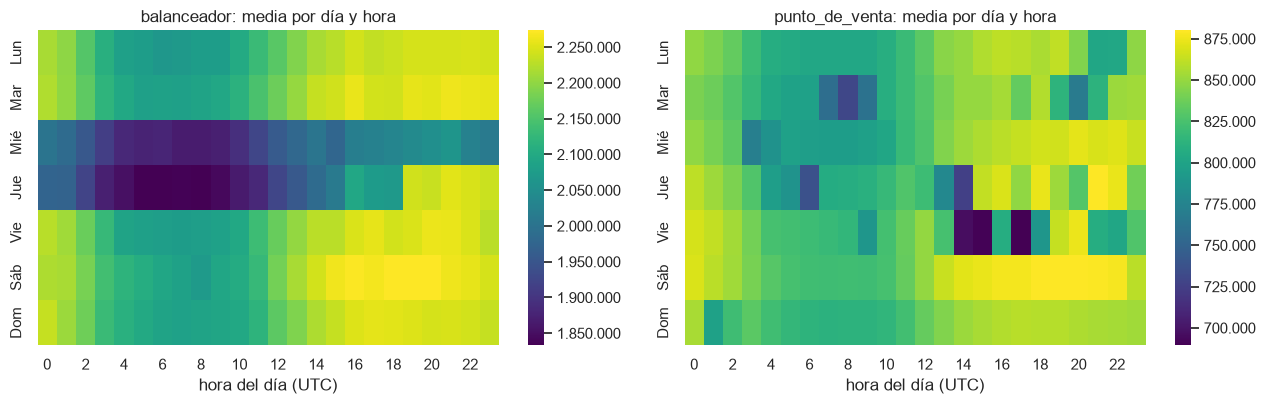

In [8]:
figura, ejes = plt.subplots(1, 2, figsize=(13, 4.2))
for eje, serie in zip(ejes, [alb, pos]):
    tabla = pd.DataFrame({"valor": serie.values, "dia": serie.index.dayofweek, "hora": serie.index.hour})
    pivote = tabla.pivot_table(index="dia", columns="hora", values="valor", aggfunc="mean")
    pivote.index = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
    sns.heatmap(pivote, ax=eje, cmap="viridis", cbar_kws={"format": MILES})
    eje.set_title(f"{serie.name}: media por día y hora")
    eje.set_xlabel("hora del día (UTC)")
    eje.set_ylabel("")
plt.tight_layout()
guardar("consolidado_heatmap")
plt.show()

El mapa de calor confirma la regularidad del ciclo diario a lo largo de la semana, y revela además un rasgo que
el trabajo no modela: en la serie del balanceador, los miércoles y jueves presentan niveles sensiblemente
inferiores. Existe un efecto de día de la semana además del ciclo diario.

Un período muestral de un mes ofrece apenas cuatro repeticiones de cada día, cantidad insuficiente para estimar
con fiabilidad una componente estacional de período 168. La limitación se retoma al analizar los residuos, donde
se manifiesta como autocorrelación remanente.

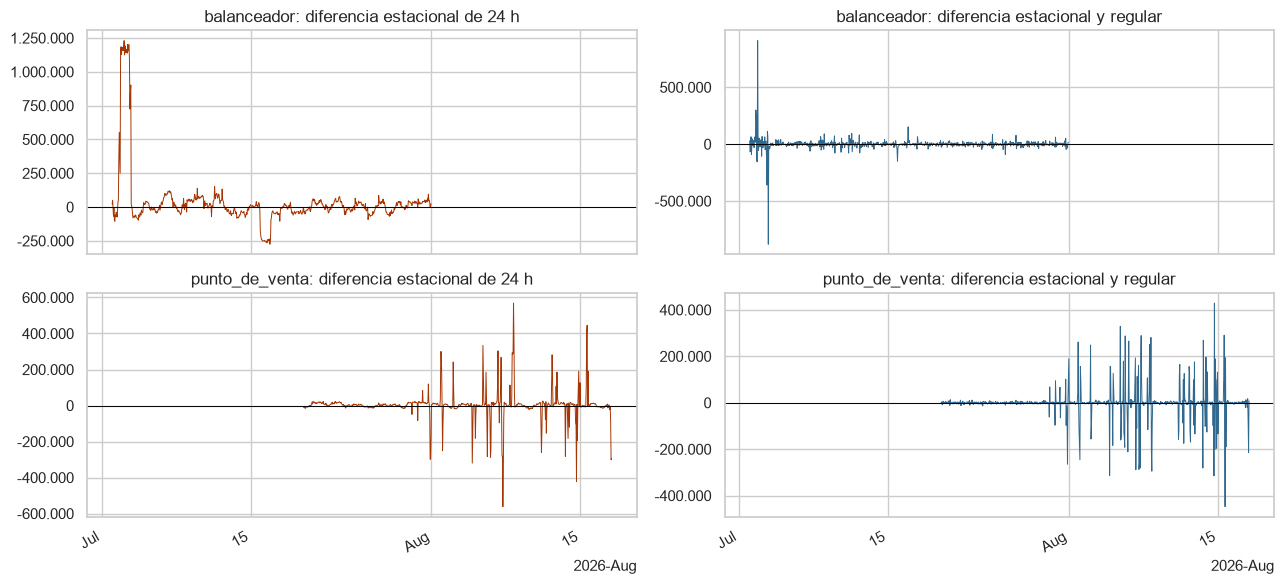

In [9]:
figura, ejes = plt.subplots(2, 2, figsize=(13, 6), sharex="col")
for fila, serie in enumerate([alb, pos]):
    ejes[fila, 0].plot(serie.diff(24).dropna(), linewidth=0.7, color="#a63603")
    ejes[fila, 0].set_title(f"{serie.name}: diferencia estacional de 24 h")
    ejes[fila, 1].plot(serie.diff(24).diff().dropna(), linewidth=0.7, color="#31688e")
    ejes[fila, 1].set_title(f"{serie.name}: diferencia estacional y regular")
    for eje in ejes[fila]:
        eje.axhline(0, color="black", linewidth=0.7)
        eje.yaxis.set_major_formatter(MILES)
        formatear_eje_temporal(eje)
plt.tight_layout()
guardar("consolidado_diferencias")
plt.show()

La diferencia estacional de veinticuatro horas elimina el ciclo; la aplicación adicional de una diferencia
regular corrige el desplazamiento residual del nivel.

### Serie de altitud

El comportamiento de la tercera serie difiere por completo. No hay ciclo repetitivo sino un recorrido con fases
sucesivas de despegue, ascenso, crucero y descenso.

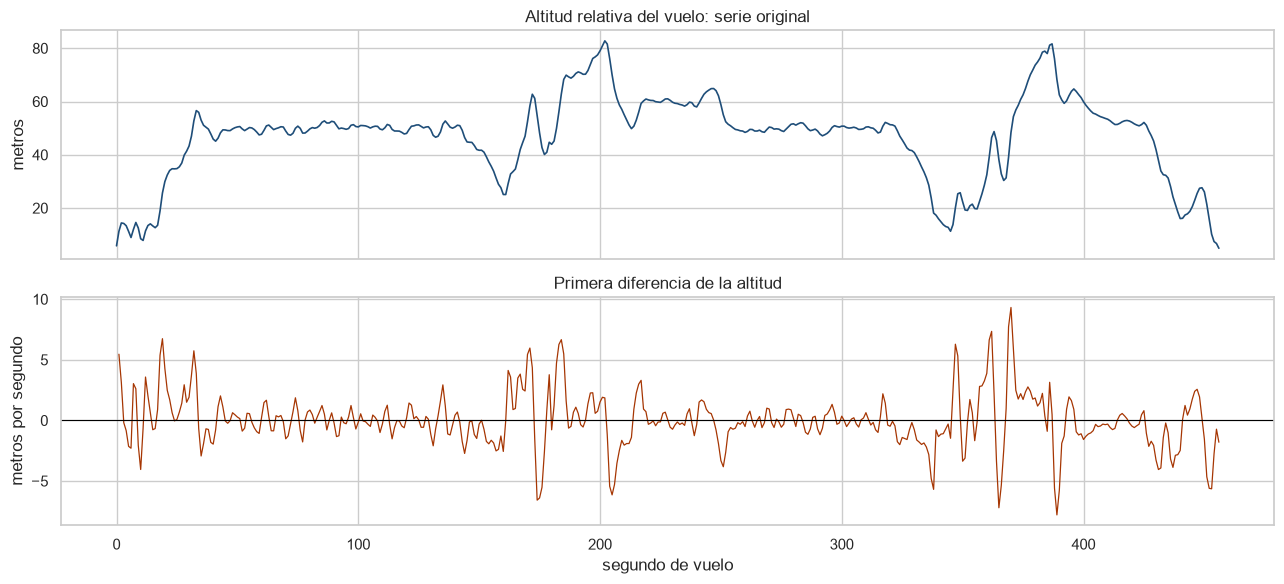

In [10]:
altitud_dif = altitud.diff().dropna()

figura, ejes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ejes[0].plot(altitud.index, altitud.values, color="#1f4e79", linewidth=1.2)
ejes[0].set_title("Altitud relativa del vuelo: serie original")
ejes[0].set_ylabel("metros")
ejes[1].plot(altitud_dif.index, altitud_dif.values, color="#a63603", linewidth=0.9)
ejes[1].axhline(0, color="black", linewidth=0.8)
ejes[1].set_title("Primera diferencia de la altitud")
ejes[1].set_ylabel("metros por segundo")
ejes[1].set_xlabel("segundo de vuelo")
plt.tight_layout()
guardar("consolidado_altitud_niveles")
plt.show()

La media se desplaza de manera sostenida a lo largo del vuelo, lo cual constituye evidencia visual de no
estacionariedad. La primera diferencia oscila en torno a cero con dispersión estable.

## 4. Funciones de autocovarianza, autocorrelación y autocorrelación parcial

*(Punto 3 de la consigna)*

Las tres funciones se presentan de manera conjunta. La **autocovarianza** mide la covariación de la serie
consigo misma a distintas distancias temporales; la **autocorrelación** la normaliza por la varianza; y la
**autocorrelación parcial** descuenta el efecto de los rezagos intermedios.

El comportamiento conjunto de las dos últimas es la herramienta primaria de identificación. Un proceso
autorregresivo presenta autocorrelación que decae de manera gradual y parcial que se corta; un proceso de medias
móviles exhibe el patrón recíproco.

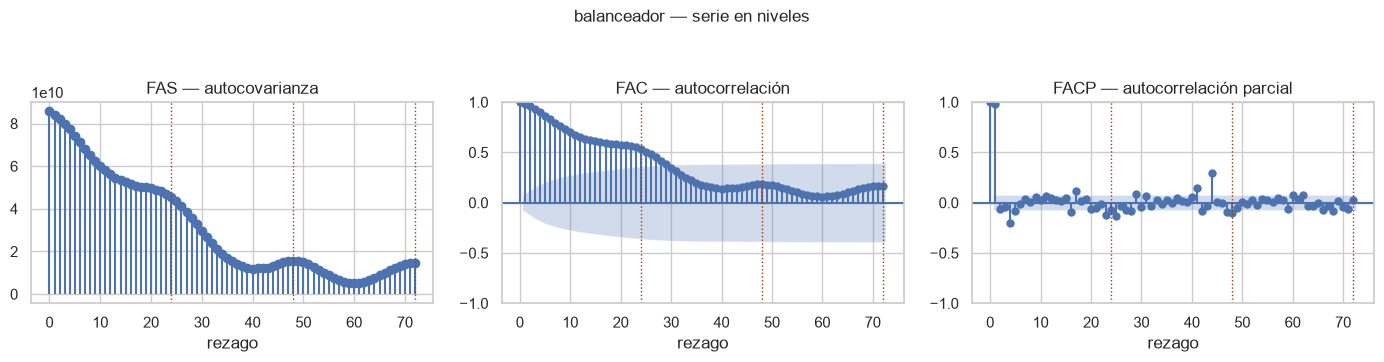

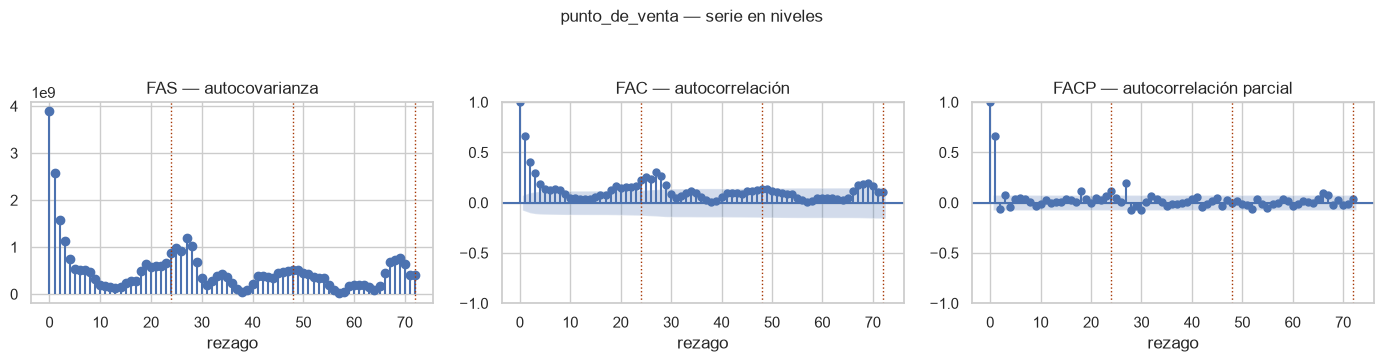

In [11]:
def graficar_fas_fac_facp(datos, titulo, rezagos=48, marcas=None):
    """Grafica la autocovarianza, la autocorrelacion y la parcial en una sola figura."""
    figura, ejes = plt.subplots(1, 3, figsize=(14, 3.4))

    autocovarianza = sm.tsa.acovf(datos, nlag=rezagos, fft=True)
    ejes[0].stem(range(len(autocovarianza)), autocovarianza, basefmt=" ")
    ejes[0].set_title("FAS — autocovarianza")

    plot_acf(datos, lags=rezagos, ax=ejes[1], title="FAC — autocorrelación")
    plot_pacf(datos, lags=rezagos, ax=ejes[2], method="ywm", title="FACP — autocorrelación parcial")

    for eje in ejes:
        eje.set_xlabel("rezago")
        for marca in (marcas or []):
            eje.axvline(marca, color="#a63603", linestyle=":", linewidth=1)

    figura.suptitle(titulo, y=1.06, fontsize=12)
    plt.tight_layout()
    return figura


for serie in [alb, pos]:
    graficar_fas_fac_facp(serie, f"{serie.name} — serie en niveles", rezagos=72, marcas=[24, 48, 72])
    guardar(f"consolidado_facs_{serie.name}")
    plt.show()

El rasgo determinante son los picos pronunciados en los rezagos 24, 48 y 72, señalados con líneas verticales.
Confirman la periodicidad diaria y fijan el período estacional en $s = 24$. La autocorrelación no decae hacia
cero entre esos picos, lo cual indica que la componente estacional domina la estructura.

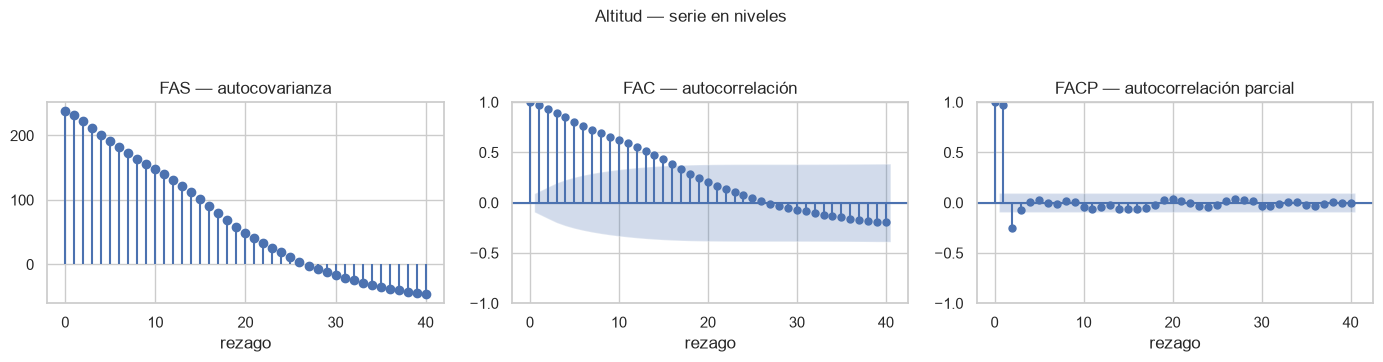

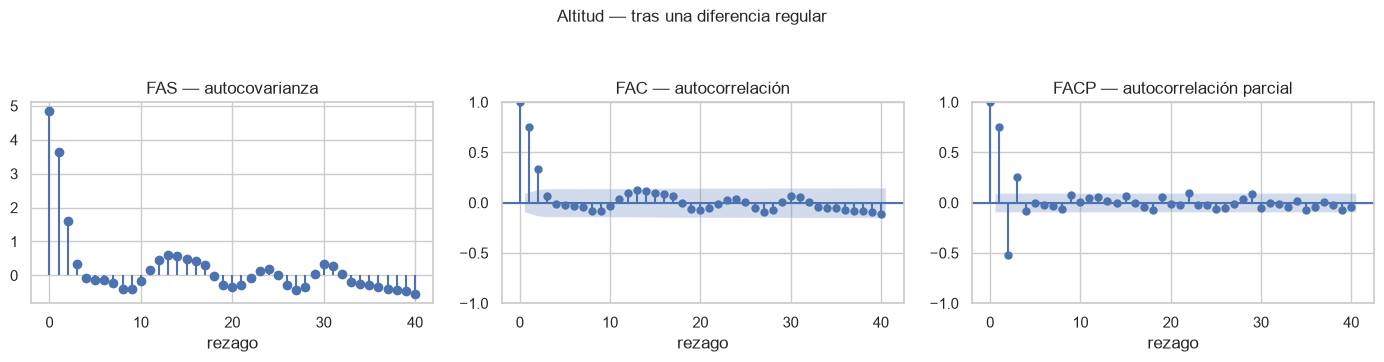

Autocorrelación de primer orden en niveles: 0.9739


In [12]:
graficar_fas_fac_facp(altitud, "Altitud — serie en niveles", rezagos=40)
guardar("consolidado_facs_altitud_niveles")
plt.show()

graficar_fas_fac_facp(altitud_dif, "Altitud — tras una diferencia regular", rezagos=40)
guardar("consolidado_facs_altitud_dif")
plt.show()

print(f"Autocorrelación de primer orden en niveles: {autocorrelacion(altitud, 1):.4f}")

Ninguna descripción ilustra el concepto con la claridad del contraste entre ambas figuras.

En niveles, la autocorrelación de primer orden se aproxima a la unidad y decae con lentitud casi lineal,
mientras la parcial exhibe un primer rezago elevado y se corta de inmediato. La teoría asocia ese par de
patrones a un **proceso integrado**: la persistencia no proviene de una memoria autorregresiva de orden elevado
sino de la presencia de una raíz unitaria, y el remedio es la diferenciación.

Tras diferenciar, la autocorrelación pierde la persistencia y conserva significatividad únicamente en los
primeros rezagos, patrón compatible con una componente de medias móviles de orden bajo. El material identificado
corresponde a un modelo ARIMA con órdenes reducidos.

## 5. Pruebas de raíces unitarias

*(Punto 4 de la consigna)*

Se aplican dos contrastes con hipótesis nulas recíprocas:

- **Dickey-Fuller aumentada (ADF)**: la nula sostiene la existencia de una raíz unitaria, esto es, la no
  estacionariedad.
- **KPSS**: la nula sostiene la estacionariedad.

Esa reciprocidad justifica su aplicación conjunta. Cuando ambas coinciden, la conclusión es sólida; cuando
discrepan, la evidencia muestral no basta para pronunciarse de manera categórica y la decisión debe apoyarse en
elementos adicionales. El uso de un único contraste induciría una lectura mecánica.

In [13]:
def contrastar_raiz_unitaria(datos, etiqueta, version):
    """Aplica ADF y KPSS sobre una serie y devuelve una fila de resultados."""
    estadistico_adf, p_adf = adfuller(datos)[0], adfuller(datos)[1]
    estadistico_kpss, p_kpss = kpss(datos, nlags="auto")[0], kpss(datos, nlags="auto")[1]
    return {
        "serie": etiqueta,
        "versión": version,
        "ADF estadístico": estadistico_adf,
        "ADF p": p_adf,
        "ADF concluye": "no estacionaria" if p_adf > 0.05 else "estacionaria",
        "KPSS estadístico": estadistico_kpss,
        "KPSS p": p_kpss,
        "KPSS concluye": "estacionaria" if p_kpss > 0.05 else "no estacionaria",
    }


filas = []
for serie in [alb, pos]:
    filas.append(contrastar_raiz_unitaria(serie, serie.name, "original"))
    filas.append(contrastar_raiz_unitaria(serie.diff().dropna(), serie.name, "diferencia regular"))
    filas.append(contrastar_raiz_unitaria(serie.diff(24).dropna(), serie.name, "diferencia estacional"))
    filas.append(contrastar_raiz_unitaria(serie.diff(24).diff().dropna(), serie.name, "ambas diferencias"))
filas.append(contrastar_raiz_unitaria(altitud, "altitud", "original"))
filas.append(contrastar_raiz_unitaria(altitud_dif, "altitud", "diferencia regular"))

raices = pd.DataFrame(filas)
display(raices.style.format({
    "ADF estadístico": "{:.2f}", "ADF p": "{:.4f}",
    "KPSS estadístico": "{:.2f}", "KPSS p": "{:.4f}"}))

,serie,versión,ADF estadístico,ADF p,ADF concluye,KPSS estadístico,KPSS p,KPSS concluye
0,balanceador,original,-4.53,0.0002,estacionaria,0.41,0.0728,estacionaria
1,balanceador,diferencia regular,-9.70,0.0000,estacionaria,0.17,0.1000,estacionaria
2,balanceador,diferencia estacional,-7.56,0.0000,estacionaria,0.54,0.0330,no estacionaria
3,balanceador,ambas diferencias,-10.10,0.0000,estacionaria,0.02,0.1000,estacionaria
4,punto_de_venta,original,-9.55,0.0000,estacionaria,2.33,0.0100,no estacionaria
5,punto_de_venta,diferencia regular,-10.82,0.0000,estacionaria,0.13,0.1000,estacionaria
6,punto_de_venta,diferencia estacional,-6.21,0.0000,estacionaria,0.02,0.1000,estacionaria
7,punto_de_venta,ambas diferencias,-10.43,0.0000,estacionaria,0.24,0.1000,estacionaria
8,altitud,original,-2.47,0.1237,no estacionaria,0.24,0.1000,estacionaria
9,altitud,diferencia regular,-8.62,0.0000,estacionaria,0.31,0.1000,estacionaria


La lectura conjunta revela matices que un contraste aislado ocultaría.

En la serie de altitud en niveles **ninguna de las dos pruebas se pronuncia**: la ADF no rechaza la raíz
unitaria y la KPSS tampoco rechaza la estacionariedad. Ante esa indefinición, la decisión de diferenciar se
sostiene sobre tres elementos convergentes: el desplazamiento visible de la media, el decaimiento lento de la
autocorrelación junto con el corte de la parcial, y la ausencia de rechazo por parte de la ADF. La literatura
recomienda diferenciar ante evidencia de raíz unitaria, porque sobrediferenciar cuesta menos que estimar sobre una serie integrada.

El resultado decisivo aparece tras diferenciar.

In [14]:
ljung_altitud = acorr_ljungbox(altitud_dif, lags=[10, 20], return_df=True)
print("Prueba de Ljung-Box sobre la altitud diferenciada:")
print(ljung_altitud.to_string())
print("\nEl rechazo indica que subsiste estructura autocorrelacionada por modelar.")

Prueba de Ljung-Box sobre la altitud diferenciada:
    lb_stat  lb_pvalue
10   319,61       0,00
20   352,92       0,00

El rechazo indica que subsiste estructura autocorrelacionada por modelar.


## 6. Estimación y selección de modelos

*(Punto 5 de la consigna)*

### 6.1 Series de tráfico

Se estima una grilla de modelos SARIMA con período estacional $s = 24$, con distintas combinaciones de
diferencia regular y estacional. La grilla se mantiene reducida de manera deliberada: la muestra abarca
aproximadamente un mes, y una búsqueda amplia sobreactuaría precisión y favorecería el sobreajuste.

La comparación emplea dos criterios complementarios. Los **criterios de información** de Akaike y bayesiano
penalizan la cantidad de parámetros y permiten contrastar modelos no anidados, pero miden el ajuste dentro de la
muestra. El **desempeño fuera de muestra**, en cambio, evalúa la capacidad predictiva efectiva.

Cuando ambos coinciden, la elección es inmediata. Cuando discrepan, se privilegia el desempeño fuera de
muestra, que atiende directamente a la finalidad predictiva del modelo. El mismo criterio se aplica más
adelante al seleccionar el orden del modelo multivariado.

In [15]:
HORIZONTE_TRAFICO = 48  # dos ciclos diarios completos

ORDENES_SARIMA = [
    ((1, 1, 1), (1, 1, 1, 24)),
    ((1, 0, 1), (1, 1, 1, 24)),
    ((1, 1, 1), (1, 0, 1, 24)),
    ((1, 0, 1), (1, 0, 1, 24)),
]


def metricas(observado, estimado):
    """Error absoluto medio, raiz del error cuadratico medio y error porcentual."""
    error = np.asarray(estimado) - np.asarray(observado)
    return {
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "MAPE_%": np.mean(np.abs(error / np.asarray(observado))) * 100,
    }


resultados_sarima = []
ajustes_sarima = {}

for serie in [alb, pos]:
    entrenamiento = serie.iloc[:-HORIZONTE_TRAFICO]
    prueba = serie.iloc[-HORIZONTE_TRAFICO:]
    for orden, estacional in ORDENES_SARIMA:
        ajuste = SARIMAX(entrenamiento, order=orden, seasonal_order=estacional,
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pronostico = ajuste.forecast(HORIZONTE_TRAFICO)
        fila = {"serie": serie.name,
                "modelo": f"SARIMA{orden}x{estacional}",
                "AIC": ajuste.aic, "BIC": ajuste.bic}
        fila.update(metricas(prueba.to_numpy(), pronostico.to_numpy()))
        resultados_sarima.append(fila)
        ajustes_sarima[(serie.name, str(orden), str(estacional))] = ajuste

# Se ordena por desempeno fuera de muestra, con el criterio de Akaike como desempate.
comparacion_sarima = (pd.DataFrame(resultados_sarima)
                      .sort_values(["serie", "MAPE_%", "AIC"])
                      .reset_index(drop=True))
display(comparacion_sarima.style.format({
    "AIC": formato_es, "BIC": formato_es,
    "MAE": formato_es_entero, "RMSE": formato_es_entero, "MAPE_%": formato_es}))

,serie,modelo,AIC,BIC,MAE,RMSE,MAPE_%
0,balanceador,"SARIMA(1, 1, 1)x(1, 1, 1, 24)","15.491,11","15.513,46",16.662,20.310,"0,79"
1,balanceador,"SARIMA(1, 0, 1)x(1, 1, 1, 24)","15.527,20","15.549,55",26.776,32.528,"1,26"
2,balanceador,"SARIMA(1, 0, 1)x(1, 0, 1, 24)","16.264,80","16.287,34",74.059,93.573,"3,64"
3,balanceador,"SARIMA(1, 1, 1)x(1, 0, 1, 24)","16.229,29","16.251,82",76.284,95.622,"3,74"
4,punto_de_venta,"SARIMA(1, 1, 1)x(1, 0, 1, 24)","15.737,10","15.759,45",29.641,58.454,"3,90"
5,punto_de_venta,"SARIMA(1, 0, 1)x(1, 0, 1, 24)","15.860,56","15.882,91",30.840,59.890,"4,08"
6,punto_de_venta,"SARIMA(1, 0, 1)x(1, 1, 1, 24)","15.381,30","15.403,47",39.594,82.710,"5,09"
7,punto_de_venta,"SARIMA(1, 1, 1)x(1, 1, 1, 24)","15.467,63","15.489,79",45.861,82.190,"5,91"


In [16]:
seleccionados = {}
for serie in [alb, pos]:
    mejor = comparacion_sarima[comparacion_sarima["serie"] == serie.name].iloc[0]
    clave = [k for k in ajustes_sarima if k[0] == serie.name and f"SARIMA{k[1]}x{k[2]}" == mejor["modelo"]][0]
    seleccionados[serie.name] = ajustes_sarima[clave]
    print(f"{serie.name:20s} -> {mejor['modelo']}"
          f"   AIC {mejor['AIC']:,.2f} | MAPE {mejor['MAPE_%']:.2f} %")

# Comparacion entre ambos criterios de seleccion.
print("\nCriterio de selección aplicado a cada serie:")
for serie in [alb, pos]:
    sub = comparacion_sarima[comparacion_sarima["serie"] == serie.name]
    por_mape = sub.iloc[0]["modelo"]
    por_aic = sub.nsmallest(1, "AIC").iloc[0]["modelo"]
    coinciden = "coinciden" if por_mape == por_aic else "DISCREPAN"
    print(f"  {serie.name:20s} MAPE -> {por_mape:32s} AIC -> {por_aic:32s} [{coinciden}]")

balanceador          -> SARIMA(1, 1, 1)x(1, 1, 1, 24)   AIC 15,491.11 | MAPE 0.79 %
punto_de_venta       -> SARIMA(1, 1, 1)x(1, 0, 1, 24)   AIC 15,737.10 | MAPE 3.90 %

Criterio de selección aplicado a cada serie:
  balanceador          MAPE -> SARIMA(1, 1, 1)x(1, 1, 1, 24)    AIC -> SARIMA(1, 1, 1)x(1, 1, 1, 24)    [coinciden]
  punto_de_venta       MAPE -> SARIMA(1, 1, 1)x(1, 0, 1, 24)    AIC -> SARIMA(1, 0, 1)x(1, 1, 1, 24)    [DISCREPAN]


In [17]:
# Significatividad individual de los parametros de los modelos seleccionados.
filas = []
for nombre, ajuste in seleccionados.items():
    for parametro in ajuste.params.index:
        filas.append({
            "serie": nombre,
            "parámetro": parametro,
            "coeficiente": ajuste.params[parametro],
            "p_valor": ajuste.pvalues[parametro],
            "significativo_5%": "sí" if ajuste.pvalues[parametro] < 0.05 else "no",
        })
parametros_sarima = pd.DataFrame(filas)
display(parametros_sarima.style.format({
    "coeficiente": lambda v: formato_es(v, 4), "p_valor": lambda v: formato_es(v, 4)}))

,serie,parámetro,coeficiente,p_valor,significativo_5%
0,balanceador,ar.L1,"-0,0833","0,9720",no
1,balanceador,ma.L1,"0,0117","0,9960",no
2,balanceador,ar.S.L24,"-0,1535","0,0000",sí
3,balanceador,ma.S.L24,"-0,5210","0,0000",sí
4,balanceador,sigma2,"3.314.618.119,2901","0,0000",sí
5,punto_de_venta,ar.L1,"0,5718","0,0000",sí
6,punto_de_venta,ma.L1,"-0,9658","0,0000",sí
7,punto_de_venta,ar.S.L24,"-0,2223","0,2102",no
8,punto_de_venta,ma.S.L24,"0,2689","0,1258",no
9,punto_de_venta,sigma2,"2.525.534.011,3282","0,0000",sí


Los dos criterios **discrepan en la serie de punto de venta**. El criterio de Akaike favorece una
especificación con diferencia estacional, mientras que el desempeño fuera de muestra favorece otra sin ella,
con un error porcentual sensiblemente menor. Se adopta esta última, conforme al criterio expuesto.

En la serie del balanceador, en cambio, ambos criterios coinciden.

El examen de significatividad arroja un resultado que conviene señalar sin atenuantes: en el modelo del
balanceador, **los parámetros de la parte regular carecen de significatividad**, mientras que los estacionales
resultan altamente significativos.

La estructura de la serie reside, pues, casi por completo en su componente estacional: la parte regular sobra. Una especificación sin componente autorregresiva ni de medias móviles
regulares habría alcanzado un ajuste equivalente con dos parámetros menos.

### 6.2 Serie de altitud

Sobre la serie de altitud se estima una grilla ARIMA con órdenes entre cero y tres y una única diferencia
regular, fijada conforme al análisis del apartado anterior.

In [18]:
HORIZONTE_ALTITUD = 15

entrenamiento_altitud = altitud.iloc[:-HORIZONTE_ALTITUD]
prueba_altitud = altitud.iloc[-HORIZONTE_ALTITUD:]

resultados_arima = []
for p in range(4):
    for q in range(4):
        try:
            ajuste = ARIMA(entrenamiento_altitud, order=(p, 1, q)).fit()
            pronostico = ajuste.forecast(HORIZONTE_ALTITUD)
            fila = {"modelo": f"ARIMA({p},1,{q})", "AIC": ajuste.aic, "BIC": ajuste.bic}
            fila.update(metricas(prueba_altitud.to_numpy(), pronostico.to_numpy()))
            fila["Ljung-Box(20) residuos p"] = acorr_ljungbox(
                ajuste.resid[1:], lags=[20], return_df=True)["lb_pvalue"].iloc[0]
            resultados_arima.append(fila)
        except (ValueError, np.linalg.LinAlgError) as excepcion:
            print(f"ARIMA({p},1,{q}) no convergió: {excepcion}")

comparacion_arima = pd.DataFrame(resultados_arima).sort_values("AIC").reset_index(drop=True)
display(comparacion_arima.head(8).style.format({
    "AIC": formato_es, "BIC": formato_es,
    "MAE": lambda v: formato_es(v, 3), "RMSE": lambda v: formato_es(v, 3),
    "MAPE_%": formato_es,
    "Ljung-Box(20) residuos p": lambda v: formato_es(v, 3)}))

,modelo,AIC,BIC,MAE,RMSE,MAPE_%,Ljung-Box(20) residuos p
0,"ARIMA(1,1,3)","1.379,95","1.400,40","6,013","7,534","61,27","0,631"
1,"ARIMA(0,1,3)","1.380,36","1.396,72","5,989","7,567","61,75","0,602"
2,"ARIMA(2,1,3)","1.381,68","1.406,21","6,004","7,552","61,56","0,653"
3,"ARIMA(3,1,3)","1.383,19","1.411,81","5,991","7,553","61,52","0,654"
4,"ARIMA(3,1,1)","1.387,43","1.407,87","6,007","7,495","60,34","0,468"
5,"ARIMA(2,1,1)","1.387,49","1.403,85","5,963","7,519","60,94","0,489"
6,"ARIMA(2,1,2)","1.387,87","1.408,31","5,983","7,518","60,91","0,437"
7,"ARIMA(3,1,0)","1.389,23","1.405,59","6,061","7,461","59,09","0,226"


In [19]:
orden_altitud = tuple(int(v) for v in comparacion_arima.loc[0, "modelo"][6:-1].split(","))
modelo_altitud = ARIMA(entrenamiento_altitud, order=orden_altitud).fit()
print(f"Modelo seleccionado por AIC: ARIMA{orden_altitud}\n")
print(modelo_altitud.summary())

Modelo seleccionado por AIC: ARIMA(1, 1, 3)

                               SARIMAX Results                                
Dep. Variable:              altitud_m   No. Observations:                  442
Model:                 ARIMA(1, 1, 3)   Log Likelihood                -684.976
Date:                Sun, 23 Aug 2026   AIC                           1379.951
Time:                        18:44:25   BIC                           1400.397
Sample:                             0   HQIC                          1388.016
                                - 442                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2650      0.120     -2.208      0.027      -0.500      -0.030
ma.L1          1.6263      0.113     14.432      0.000       1.405       1.847
ma.L2  

### 6.3 Significatividad global

La significatividad individual, visible en el cuadro de coeficientes, no agota lo que la consigna solicita. La
evaluación **global** requiere un contraste sobre el conjunto de parámetros.

Se emplea la razón de verosimilitud, que compara el modelo estimado contra una versión restringida en la que
todos los parámetros autorregresivos y de medias móviles son nulos. El modelo restringido equivale a un paseo
aleatorio. El estadístico se distribuye como una chi-cuadrado con tantos grados de libertad como restricciones
impuestas.

In [20]:
modelo_nulo = ARIMA(entrenamiento_altitud, order=(0, 1, 0)).fit()

estadistico_lr = 2 * (modelo_altitud.llf - modelo_nulo.llf)
grados_libertad = len(modelo_altitud.params) - len(modelo_nulo.params)
p_valor_lr = stats.chi2.sf(estadistico_lr, grados_libertad)

print(f"Log-verosimilitud ARIMA{orden_altitud} : {modelo_altitud.llf:10.3f}")
print(f"Log-verosimilitud ARIMA(0,1,0)    : {modelo_nulo.llf:10.3f}")
print(f"Estadístico LR                    : {estadistico_lr:10.2f}")
print(f"Grados de libertad                : {grados_libertad:10d}")
print(f"Valor p (chi-cuadrado)            : {p_valor_lr:10.3e}")

Log-verosimilitud ARIMA(1, 1, 3) :   -684.976
Log-verosimilitud ARIMA(0,1,0)    :   -968.532
Estadístico LR                    :     567.11
Grados de libertad                :          4
Valor p (chi-cuadrado)            : 2.029e-121


## 7. Desempeño y comparación entre modelos

*(Puntos 6 y 7 de la consigna)*

La partición reserva las últimas 48 horas en las series de tráfico, equivalentes a dos ciclos diarios completos,
y los últimos 15 segundos en la de altitud, poco más del tres por ciento de la muestra. Ambos horizontes guardan
proporción con la frecuencia de muestreo y con el tamaño de la muestra.

In [21]:
filas = []
for serie in [alb, pos]:
    ajuste = seleccionados[serie.name]
    prueba = serie.iloc[-HORIZONTE_TRAFICO:]
    pronostico = ajuste.forecast(HORIZONTE_TRAFICO)
    fila = {"serie": serie.name, "horizonte": f"{HORIZONTE_TRAFICO} h"}
    fila.update(metricas(prueba.to_numpy(), pronostico.to_numpy()))
    filas.append(fila)

pronostico_altitud = modelo_altitud.forecast(HORIZONTE_ALTITUD)
fila = {"serie": "altitud (m)", "horizonte": f"{HORIZONTE_ALTITUD} s"}
fila.update(metricas(prueba_altitud.to_numpy(), pronostico_altitud.to_numpy()))
filas.append(fila)

desempeno = pd.DataFrame(filas)
display(desempeno.style.format({"MAE": formato_es, "RMSE": formato_es, "MAPE_%": formato_es}))

,serie,horizonte,MAE,RMSE,MAPE_%
0,balanceador,48 h,"16.662,34","20.309,65","0,79"
1,punto_de_venta,48 h,"29.640,50","58.453,68","3,90"
2,altitud (m),15 s,"6,01","7,53","61,27"


La comparación entre especificaciones, presentada en el apartado anterior, muestra que la diferencia de
desempeño resulta considerable entre modelos con y sin diferencia estacional: en la serie del balanceador, el
error absoluto medio se multiplica por más de cuatro al omitirla. La componente estacional constituye el
elemento decisivo del ajuste.

En la serie de altitud, en cambio, las diferencias entre órdenes vecinos son mínimas. El desempeño predictivo no
discrimina, y el criterio de información opera como desempate en favor de la especificación más parsimoniosa.

Corresponde advertir que el conjunto de prueba de la serie de altitud coincide con la fase de descenso,
dinámicamente distinta del crucero donde el modelo se entrena de manera mayoritaria. La métrica obtenida peca, pues, de conservadora.

## 8. Análisis de diagnóstico

*(Punto 8 de la consigna)*

Si el modelo captura adecuadamente la estructura de la serie, sus residuos deben comportarse como ruido blanco:
media nula, varianza constante y ausencia de autocorrelación. Todo apartamiento indica estructura sin explicar.

El diagnóstico arroja resultados netamente distintos entre las series de tráfico y la de altitud, y conviene
exponerlos por separado en lugar de uniformarlos.

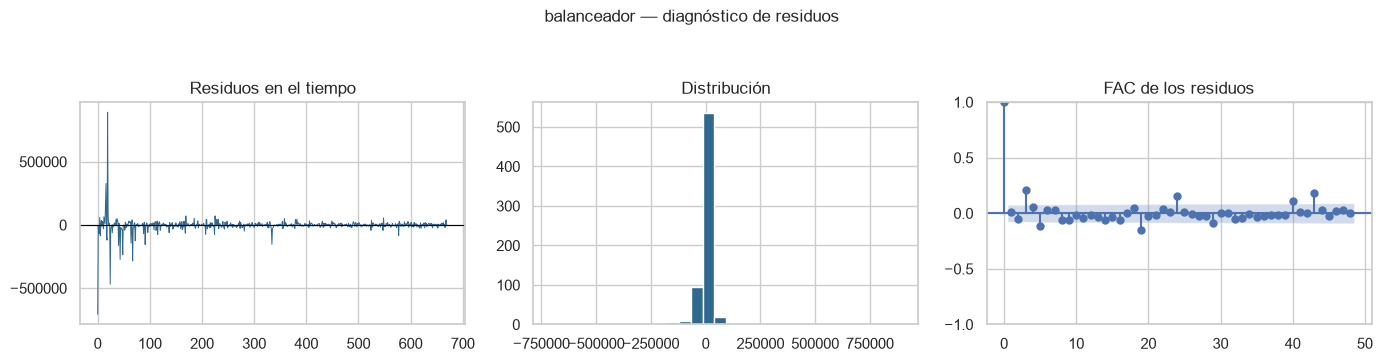

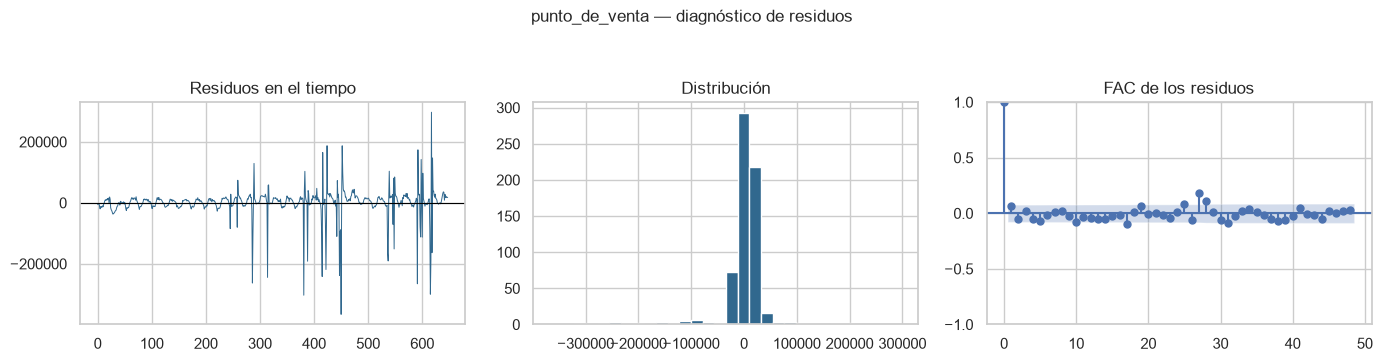

,serie,rezago,Ljung-Box,p_valor
0,balanceador,12,"51,67","0,0000"
1,balanceador,24,"94,76","0,0000"
2,balanceador,48,"140,69","0,0000"
3,punto_de_venta,12,"16,36","0,1754"
4,punto_de_venta,24,"30,19","0,1785"
5,punto_de_venta,48,"91,66","0,0002"


In [22]:
def diagnosticar(residuos, titulo, rezagos_fac=48):
    """Grafica residuos, distribucion y FAC, y devuelve la prueba de Ljung-Box."""
    figura, ejes = plt.subplots(1, 3, figsize=(14, 3.4))
    ejes[0].plot(residuos.values, linewidth=0.7, color="#31688e")
    ejes[0].axhline(0, color="black", linewidth=0.8)
    ejes[0].set_title("Residuos en el tiempo")
    ejes[1].hist(residuos.values, bins=30, color="#31688e", edgecolor="white")
    ejes[1].set_title("Distribución")
    plot_acf(residuos, lags=rezagos_fac, ax=ejes[2], title="FAC de los residuos")
    figura.suptitle(titulo, y=1.06, fontsize=12)
    plt.tight_layout()
    return acorr_ljungbox(residuos, lags=[12, 24, 48], return_df=True)


filas_ljung = []
for serie in [alb, pos]:
    residuos = seleccionados[serie.name].resid[24:]
    prueba_lb = diagnosticar(residuos, f"{serie.name} — diagnóstico de residuos")
    guardar(f"consolidado_residuos_{serie.name}")
    plt.show()
    for rezago, fila in prueba_lb.iterrows():
        filas_ljung.append({"serie": serie.name, "rezago": rezago,
                            "Ljung-Box": fila["lb_stat"], "p_valor": fila["lb_pvalue"]})

display(pd.DataFrame(filas_ljung).style.format({
    "Ljung-Box": formato_es, "p_valor": lambda v: formato_es(v, 4)}))

El resultado es desfavorable y así debe consignarse. Ambos modelos **dejan estructura sin explicar**,
concentrada en los rezagos correspondientes al ciclo diario y a sus múltiplos.

El patrón concuerda con lo observado en el mapa de calor: existe una componente
semanal que los modelos no capturan, y que se manifiesta como autocorrelación residual en los rezagos
estacionales. En consecuencia, los pronósticos de estas dos series merecen menor confianza que la sugerida por
sus métricas de error, y sus intervalos de predicción resultan probablemente estrechos.

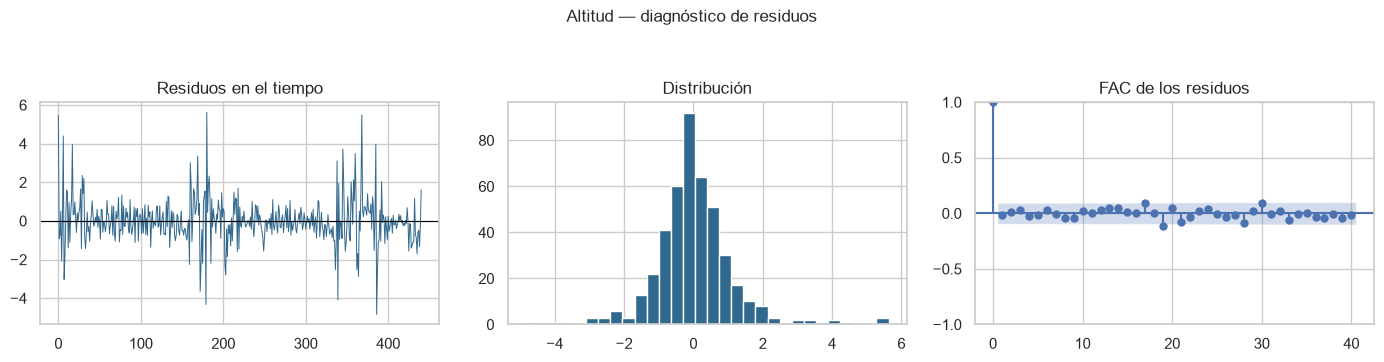

Media de los residuos : 0.0136 m
Desvío estándar       : 1.1644 m



,lb_stat,lb_pvalue
12,"3,717","0,9880"
24,"21,167","0,6289"
48,"49,336","0,4195"


In [23]:
residuos_altitud = modelo_altitud.resid[1:]
prueba_lb_altitud = diagnosticar(residuos_altitud, "Altitud — diagnóstico de residuos", rezagos_fac=40)
guardar("consolidado_residuos_altitud")
plt.show()

print(f"Media de los residuos : {residuos_altitud.mean():.4f} m")
print(f"Desvío estándar       : {residuos_altitud.std():.4f} m\n")
display(prueba_lb_altitud.style.format({
    "lb_stat": lambda v: formato_es(v, 3), "lb_pvalue": lambda v: formato_es(v, 4)}))

El modelo de la serie de altitud arroja el resultado opuesto: la prueba no rechaza la incorrelación en ninguno
de los rezagos examinados, y los residuos resultan indistinguibles del ruido blanco. Es el único de los tres
modelos que supera el diagnóstico de manera completa.

El contraste de Jarque-Bera, visible en el resumen del modelo, rechaza en cambio la normalidad. Los
apartamientos se concentran en las colas y resultan atribuibles a las maniobras del vuelo; afectan la validez de
los intervalos de confianza nominales, no la estimación puntual.

## 9. Pronóstico

*(Punto 9 de la consigna)*

Las ventanas de pronóstico responden a la periodicidad de cada serie. En las series horarias, 48 horas cubren
dos ciclos diarios completos y permiten verificar si el modelo reproduce la periodicidad. En la serie de
altitud, 15 segundos constituyen una ventana de anticipación razonable para la supervisión de un vuelo; un
horizonte más extenso degrada la precisión con rapidez, dado que la trayectoria depende de decisiones del plan
de vuelo que el modelo no observa.

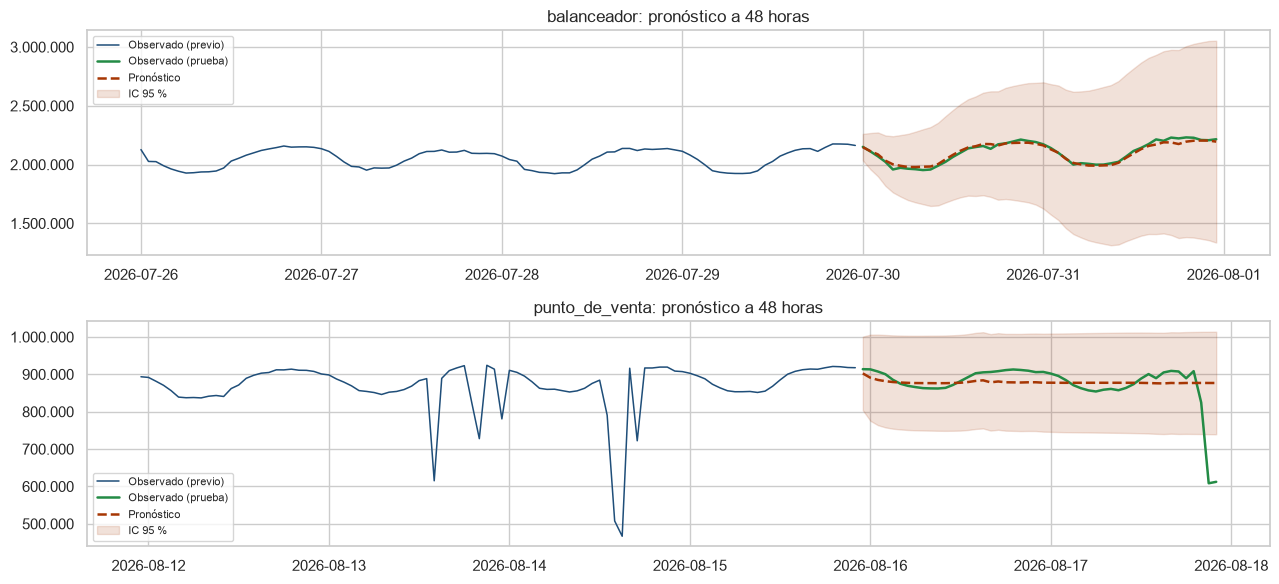

In [24]:
figura, ejes = plt.subplots(2, 1, figsize=(13, 6))
for eje, serie in zip(ejes, [alb, pos]):
    ajuste = seleccionados[serie.name]
    prediccion = ajuste.get_forecast(HORIZONTE_TRAFICO)
    intervalo = prediccion.conf_int()
    contexto = serie.iloc[-HORIZONTE_TRAFICO - 96:-HORIZONTE_TRAFICO]
    prueba = serie.iloc[-HORIZONTE_TRAFICO:]

    eje.plot(contexto.index, contexto.values, color="#1f4e79", linewidth=1.1, label="Observado (previo)")
    eje.plot(prueba.index, prueba.values, color="#238b45", linewidth=1.8, label="Observado (prueba)")
    eje.plot(prueba.index, prediccion.predicted_mean.to_numpy(), color="#a63603",
             linewidth=1.8, linestyle="--", label="Pronóstico")
    eje.fill_between(prueba.index, intervalo.iloc[:, 0], intervalo.iloc[:, 1],
                     color="#a63603", alpha=0.15, label="IC 95 %")
    eje.set_title(f"{serie.name}: pronóstico a {HORIZONTE_TRAFICO} horas")
    eje.yaxis.set_major_formatter(MILES)
    eje.legend(loc="best", fontsize=8)
plt.tight_layout()
guardar("consolidado_pronostico_trafico")
plt.show()

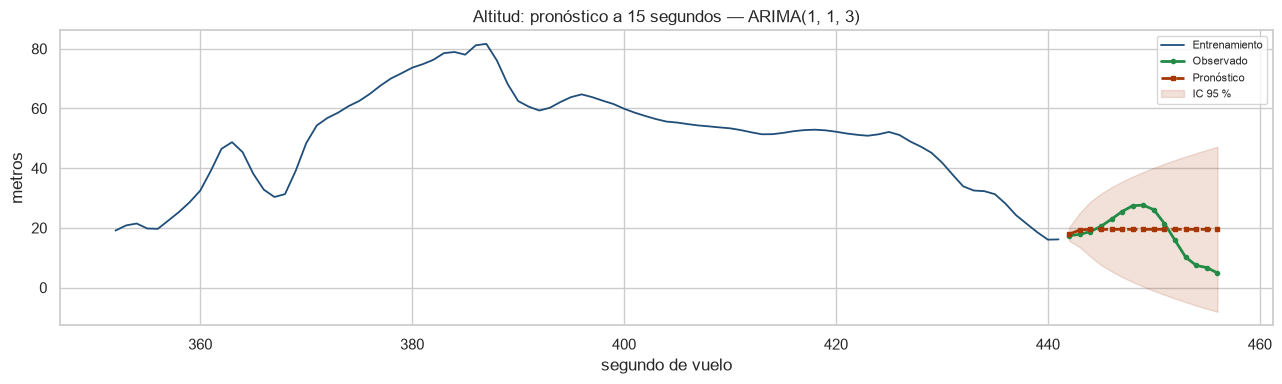

In [25]:
prediccion_altitud = modelo_altitud.get_forecast(HORIZONTE_ALTITUD)
intervalo_altitud = prediccion_altitud.conf_int()
contexto = entrenamiento_altitud.iloc[-90:]

figura, eje = plt.subplots(figsize=(13, 4))
eje.plot(contexto.index, contexto.values, color="#1f4e79", linewidth=1.3, label="Entrenamiento")
eje.plot(prueba_altitud.index, prueba_altitud.values, color="#238b45", linewidth=2,
         marker="o", markersize=3, label="Observado")
eje.plot(prueba_altitud.index, prediccion_altitud.predicted_mean.to_numpy(), color="#a63603",
         linewidth=2, linestyle="--", marker="s", markersize=3, label="Pronóstico")
eje.fill_between(prueba_altitud.index, intervalo_altitud.iloc[:, 0], intervalo_altitud.iloc[:, 1],
                 color="#a63603", alpha=0.15, label="IC 95 %")
eje.set_title(f"Altitud: pronóstico a {HORIZONTE_ALTITUD} segundos — ARIMA{orden_altitud}")
eje.set_xlabel("segundo de vuelo")
eje.set_ylabel("metros")
eje.legend(loc="best", fontsize=8)
plt.tight_layout()
guardar("consolidado_pronostico_altitud")
plt.show()

## 10. Modelo de vectores autorregresivos

*(Puntos 10 y 11 de la consigna)*

### 10.1 Alcance y restricción de calendario

El modelo multivariado se construye sobre las dos series de tráfico. **La serie de altitud queda excluida** por
una razón que no admite solución dentro del conjunto de datos disponible: fue registrada en 2018, mientras que
las series de tráfico corresponden a 2026. Los calendarios son disjuntos y no comparten un solo instante de
observación. Un modelo de vectores autorregresivos exige series alineadas sobre el mismo eje temporal.

Las dos series de tráfico tampoco coinciden por completo, de modo que se trabaja sobre su intersección temporal.

La transformación previa cumple dos funciones: el logaritmo estabiliza la escala, dado que ambas series difieren
en un orden de magnitud, y la diferencia estacional de veinticuatro horas las vuelve estacionarias, requisito
del modelo.

In [26]:
alineadas = pd.concat([alb, pos], axis=1, join="inner").dropna()
log_alineadas = np.log1p(alineadas)
datos_var = log_alineadas.diff(24).dropna()

print(f"Rango de la primera serie : {alb.index.min()} a {alb.index.max()}")
print(f"Rango de la segunda serie : {pos.index.min()} a {pos.index.max()}")
print(f"Rango común               : {alineadas.index.min()} a {alineadas.index.max()}")
print(f"Días de solapamiento      : {(alineadas.index.max() - alineadas.index.min()).days}")
print(f"Observaciones tras transformar: {len(datos_var)}")

Rango de la primera serie : 2026-07-01 00:00:00+00:00 a 2026-07-31 23:00:00+00:00
Rango de la segunda serie : 2026-07-18 23:00:00+00:00 a 2026-08-17 22:00:00+00:00
Rango común               : 2026-07-18 23:00:00+00:00 a 2026-07-31 23:00:00+00:00
Días de solapamiento      : 13
Observaciones tras transformar: 289


### 10.2 Selección del orden de rezagos

Los criterios de selección no coinciden, y la discrepancia tiene consecuencias considerables. Con dos variables
y $p$ rezagos, el modelo estima $K(Kp+1)$ parámetros. Con veinticuatro rezagos la cifra asciende a 98, sobre
poco más de doscientas observaciones de entrenamiento.

In [27]:
HORIZONTE_VAR = 48
entrenamiento_var = datos_var.iloc[:-HORIZONTE_VAR]
prueba_var = datos_var.iloc[-HORIZONTE_VAR:]

seleccion = VAR(entrenamiento_var).select_order(maxlags=24)
print("Rezagos sugeridos por cada criterio:")
for criterio, valor in seleccion.selected_orders.items():
    print(f"  {criterio.upper():6s} -> {int(valor)}")

Rezagos sugeridos por cada criterio:
  AIC    -> 24
  BIC    -> 2
  HQIC   -> 2
  FPE    -> 24


El desempeño fuera de muestra resuelve el empate. La evaluación exige, sin embargo, una precaución sobre la
medición del error.

**Las métricas deben calcularse sobre la escala original.** Aplicadas sobre la serie transformada, que oscila en
torno a cero, el error porcentual absoluto medio se vuelve inestable: al dividir por un denominador próximo a
cero, arroja valores que no reflejan la calidad del modelo sino la inadecuación de la métrica. La función
siguiente invierte la transformación antes de medir.

La inversión recupera el logaritmo mediante la suma del valor rezagado veinticuatro horas más la diferencia
pronosticada, y aplica luego la exponencial. Más allá del horizonte de veinticuatro pasos el procedimiento se
vuelve recursivo, puesto que el valor rezagado ya es un pronóstico.

In [28]:
def evaluar_var(rezagos):
    """Ajusta un VAR, invierte la transformacion y mide el error en la escala original."""
    ajuste = VAR(entrenamiento_var).fit(rezagos)
    pronostico = pd.DataFrame(
        ajuste.forecast(entrenamiento_var.values[-rezagos:], HORIZONTE_VAR),
        index=prueba_var.index, columns=prueba_var.columns)

    filas = []
    for columna in prueba_var.columns:
        historico = log_alineadas[columna].copy()
        prediccion = []
        for i, instante in enumerate(prueba_var.index):
            base = historico.loc[instante - pd.Timedelta(hours=24)]
            valor = base + pronostico[columna].iloc[i]
            historico.loc[instante] = valor
            prediccion.append(valor)

        estimado = np.expm1(np.array(prediccion))
        observado = alineadas[columna].reindex(prueba_var.index).to_numpy()
        fila = {"rezagos": rezagos, "parámetros": ajuste.params.size,
                "serie": columna, "AIC": ajuste.aic}
        fila.update(metricas(observado, estimado))
        filas.append(fila)
    return filas


comparacion_var = pd.DataFrame(
    [fila for p in [1, 2, 3, 24] for fila in evaluar_var(p)])
display(comparacion_var.style.format({
    "AIC": formato_es, "MAE": formato_es_entero,
    "RMSE": formato_es_entero, "MAPE_%": formato_es}))

,rezagos,parámetros,serie,AIC,MAE,RMSE,MAPE_%
0,1,6,balanceador,"-20,45",31.287,38.462,"1,48"
1,1,6,punto_de_venta,"-20,45",32.128,67.458,"4,67"
2,2,10,balanceador,"-20,50",27.826,34.879,"1,31"
3,2,10,punto_de_venta,"-20,50",31.454,67.547,"4,59"
4,3,14,balanceador,"-20,50",26.275,33.222,"1,24"
5,3,14,punto_de_venta,"-20,50",30.781,67.668,"4,51"
6,24,98,balanceador,"-20,61",36.008,41.838,"1,71"
7,24,98,punto_de_venta,"-20,61",26.932,66.343,"4,03"


El resultado es un caso de manual de **sobreajuste**. La especificación con veinticuatro rezagos, pese a
emplear casi diez veces más parámetros, predice *peor* la serie del balanceador que la de dos rezagos. Su
ventaja sobre la segunda serie es marginal y no compensa el costo en parsimonia.

Se adopta la especificación con **dos rezagos**, respaldada por dos criterios de información y por el desempeño
fuera de muestra. La alternativa de tres rezagos mejora levemente ambas métricas, pero ningún criterio de
información la respalda, y la diferencia no justifica apartarse del criterio.

Los criterios de información constituyen una guía, no un veredicto. Ante discrepancia entre ellos, el desempeño
fuera de muestra resulta el árbitro más confiable.

In [29]:
REZAGOS_VAR = 2
modelo_var = VAR(entrenamiento_var).fit(REZAGOS_VAR)

print(f"VAR({REZAGOS_VAR}): {modelo_var.params.size} parámetros sobre {len(entrenamiento_var)} observaciones")
print(f"AIC {modelo_var.aic:.3f} | BIC {modelo_var.bic:.3f}\n")

coeficientes = []
for ecuacion in modelo_var.params.columns:
    for parametro in modelo_var.params.index:
        coeficientes.append({
            "ecuación": ecuacion,
            "parámetro": parametro,
            "coeficiente": modelo_var.params.loc[parametro, ecuacion],
            "p_valor": modelo_var.pvalues.loc[parametro, ecuacion],
        })
display(pd.DataFrame(coeficientes).style.format({"coeficiente": "{:+.4f}", "p_valor": "{:.4f}"}))

VAR(2): 10 parámetros sobre 241 observaciones
AIC -20.502 | BIC -20.357



,ecuación,parámetro,coeficiente,p_valor
0,balanceador,const,-0.0000,0.9494
1,balanceador,L1.balanceador,+0.5888,0.0000
2,balanceador,L1.punto_de_venta,+0.2977,0.0113
3,balanceador,L2.balanceador,+0.2705,0.0003
4,balanceador,L2.punto_de_venta,-0.2039,0.0844
5,punto_de_venta,const,+0.0004,0.2540
6,punto_de_venta,L1.balanceador,+0.0087,0.8561
7,punto_de_venta,L1.punto_de_venta,+0.8078,0.0000
8,punto_de_venta,L2.balanceador,-0.0157,0.7425
9,punto_de_venta,L2.punto_de_venta,+0.1095,0.1526


### 10.3 Función impulso-respuesta

La función impulso-respuesta describe la trayectoria de cada variable ante una perturbación unitaria en otra, y
permite leer la dinámica del sistema más allá de los coeficientes individuales. Se emplea la versión
ortogonalizada, que descompone las perturbaciones de modo que resulten contemporáneamente incorreladas.

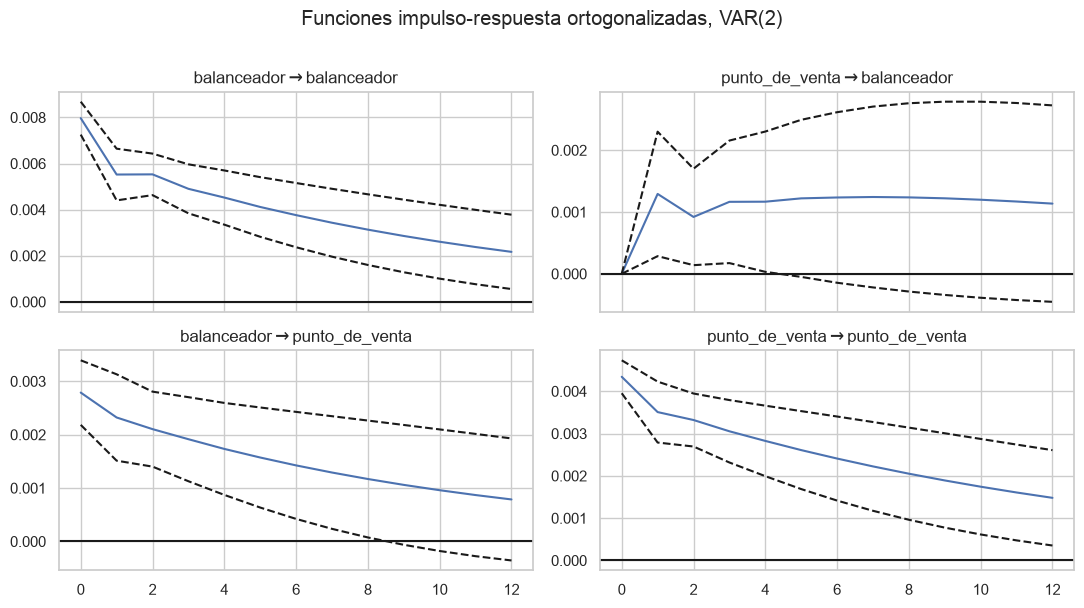

In [30]:
respuesta = modelo_var.irf(12)
respuesta.plot(orth=True, figsize=(11, 6))
plt.suptitle(f"Funciones impulso-respuesta ortogonalizadas, VAR({REZAGOS_VAR})", y=1.01)
plt.tight_layout()
guardar("consolidado_irf")
plt.show()

Las respuestas se extinguen con rapidez, comportamiento esperable en una especificación de orden bajo sobre series ya estacionarias.

### 10.4 Causalidad de Granger

El contraste evalúa si los rezagos de una variable mejoran la predicción de otra, más allá de lo que aportan los
rezagos propios de esta última. La hipótesis nula sostiene que los coeficientes asociados son conjuntamente
nulos.

In [31]:
filas = []
for causada in datos_var.columns:
    causante = [c for c in datos_var.columns if c != causada]
    prueba = modelo_var.test_causality(caused=causada, causing=causante, kind="f")
    filas.append({
        "variable causante": causante[0],
        "variable causada": causada,
        "estadístico F": prueba.test_statistic,
        "p_valor": prueba.pvalue,
        "decisión al 5%": "rechaza H0" if prueba.pvalue < 0.05 else "no rechaza H0",
    })
display(pd.DataFrame(filas).style.format({
    "estadístico F": lambda v: formato_es(v, 3), "p_valor": lambda v: formato_es(v, 4)}))

,variable causante,variable causada,estadístico F,p_valor,decisión al 5%
0,punto_de_venta,balanceador,"3,554","0,0294",rechaza H0
1,balanceador,punto_de_venta,"0,065","0,9369",no rechaza H0


El resultado es **unidireccional**: los rezagos de la serie de punto de venta contribuyen a explicar la serie
del balanceador, mientras que la relación inversa no alcanza significatividad.

La interpretación admite una lectura operativa plausible: el tráfico de la interfaz de punto de venta es una porción del tráfico total que atraviesa el balanceador, de modo que un movimiento en el primero antecede a
un movimiento en el agregado.

Conviene subrayar, no obstante, que **la causalidad de Granger establece precedencia temporal con contenido
predictivo, no causalidad en sentido estructural**. Con trece días de solapamiento, la evidencia debe
considerarse indicativa.

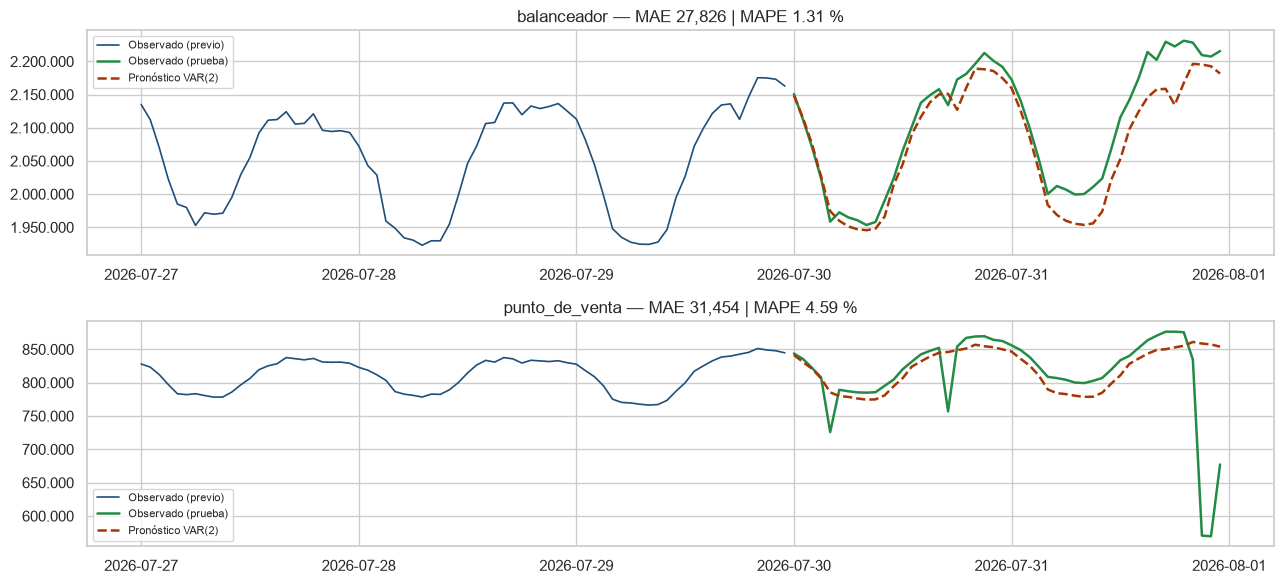

In [32]:
figura, ejes = plt.subplots(2, 1, figsize=(13, 6))
pronostico_var = pd.DataFrame(
    modelo_var.forecast(entrenamiento_var.values[-REZAGOS_VAR:], HORIZONTE_VAR),
    index=prueba_var.index, columns=prueba_var.columns)

for eje, columna in zip(ejes, prueba_var.columns):
    historico = log_alineadas[columna].copy()
    prediccion = []
    for i, instante in enumerate(prueba_var.index):
        base = historico.loc[instante - pd.Timedelta(hours=24)]
        valor = base + pronostico_var[columna].iloc[i]
        historico.loc[instante] = valor
        prediccion.append(valor)
    estimado = np.expm1(np.array(prediccion))
    observado = alineadas[columna].reindex(prueba_var.index).to_numpy()
    contexto = alineadas[columna].iloc[-HORIZONTE_VAR - 72:-HORIZONTE_VAR]

    eje.plot(contexto.index, contexto.values, color="#1f4e79", linewidth=1.2, label="Observado (previo)")
    eje.plot(prueba_var.index, observado, color="#238b45", linewidth=1.8, label="Observado (prueba)")
    eje.plot(prueba_var.index, estimado, color="#a63603", linewidth=1.8,
             linestyle="--", label=f"Pronóstico VAR({REZAGOS_VAR})")
    resultado = metricas(observado, estimado)
    eje.set_title(f"{columna} — MAE {resultado['MAE']:,.0f} | MAPE {resultado['MAPE_%']:.2f} %")
    eje.yaxis.set_major_formatter(MILES)
    eje.legend(loc="best", fontsize=8)
plt.tight_layout()
guardar("consolidado_var_pronostico")
plt.show()

## 11. Estacionalidad y representación mediante SARIMA

*(Punto 12 de la consigna)*

Las dos series de tráfico presentan estacionalidad diaria y quedan representadas por modelos SARIMA con período
$s = 24$. La comparación solicitada refiere a los modelos determinados con anterioridad **dentro de este mismo
trabajo**, esto es, a las especificaciones sin diferencia estacional evaluadas en la grilla del apartado 7.

In [33]:
comparacion_estacional = comparacion_sarima.copy()
comparacion_estacional["diferencia estacional"] = comparacion_estacional["modelo"].str.contains(r"\(1, 1, 1, 24\)")
resumen_estacional = (
    comparacion_estacional
    .groupby(["serie", "diferencia estacional"])[["AIC", "MAE", "MAPE_%"]]
    .min()
    .reset_index()
)
display(resumen_estacional.style.format(
    {"AIC": formato_es, "MAE": formato_es_entero, "MAPE_%": formato_es}))

,serie,diferencia estacional,AIC,MAE,MAPE_%
0,balanceador,False,"16.229,29",74.059,"3,64"
1,balanceador,True,"15.491,11",16.662,"0,79"
2,punto_de_venta,False,"15.737,10",29.641,"3,90"
3,punto_de_venta,True,"15.381,30",39.594,"5,09"


La comparación resulta concluyente: la incorporación de la componente estacional constituye el factor
determinante del ajuste.

La serie de altitud, en cambio, **carece de estacionalidad**. La búsqueda de periodicidad mediante periodograma
sobre la serie diferenciada arroja picos que no se verifican en la función de autocorrelación.

In [34]:
frecuencias, potencia = periodogram(altitud_dif.values - altitud_dif.values.mean(), fs=1.0)
banda_util = (frecuencias > 1 / 200) & (frecuencias < 0.4)
periodo_dominante = 1 / frecuencias[banda_util][np.argmax(potencia[banda_util])]

print(f"Período dominante según el periodograma : {periodo_dominante:.1f} s")
print(f"FAC de la serie diferenciada en ese rezago: {autocorrelacion(altitud_dif, int(round(periodo_dominante))):+.4f}")
print(f"Banda de significatividad                : +/- {1.96 / np.sqrt(len(altitud_dif)):.4f}")
print("\nEl coeficiente permanece dentro de la banda: el pico del periodograma es espurio.")

Período dominante según el periodograma : 16.3 s
FAC de la serie diferenciada en ese rezago: +0.0863
Banda de significatividad                : +/- 0.0918

El coeficiente permanece dentro de la banda: el pico del periodograma es espurio.


El pico del periodograma no se verifica en la función de autocorrelación, lo cual lo identifica como espurio.
Leer el periodograma de manera aislada, sin contrastarlo contra la autocorrelación, conduciría a postular una
estacionalidad inexistente.

La ausencia responde a la naturaleza del fenómeno: la altitud de una aeronave durante un vuelo único obedece al
plan de vuelo y a la acción del piloto automático, sin ciclo repetitivo de período fijo. La representación adecuada es, pues, un modelo ARIMA sin componente estacional.

---

## Síntesis

| Serie | Modelo seleccionado | Diagnóstico de residuos | Desempeño |
|---|---|---|---|
| Balanceador de carga | SARIMA$(1,1,1)\times(1,1,1)_{24}$ | Rechaza a partir del rezago 24 | MAPE 0,79 % a 48 h |
| Punto de venta | SARIMA$(1,1,1)\times(1,0,1)_{24}$ | Rechaza en todos los rezagos | MAPE 3,90 % a 48 h |
| Altitud de vuelo | ARIMA$(1,1,3)$ | No rechaza en ningún rezago | MAE 6,01 m a 15 s |
| Conjunto (dos series) | VAR(2) sobre transformación estacionaria | — | MAPE 1,31 % y 4,59 % a 48 h |

### Dos lecciones metodológicas

**Los criterios de información son una guía, no un veredicto.** El criterio de Akaike sugería veinticuatro
rezagos para el modelo multivariado, esto es, 98 parámetros. La especificación resultante predecía peor que una
de diez parámetros.

**Una métrica mal elegida puede invertir la lectura de un resultado.** El error porcentual calculado sobre una
serie que oscila alrededor de cero no mide la calidad del modelo sino la inadecuación de la métrica.

### Límites

El tamaño muestral de las tres series impide la validación mediante ventanas móviles. La estacionalidad semanal
que el mapa de calor revela no se modela, por insuficiencia de repeticiones, y su omisión explica la
autocorrelación residual detectada. El solapamiento entre las series de tráfico abarca trece días, lo cual
condiciona toda conclusión del modelo multivariado. La serie de altitud describe un único vuelo y no se
generaliza.